# Potato Disease Prediction Model

Train a CNN to classify potato leaf images into disease classes. Class folders are read from `data/potato` (e.g. Potato___Early_blight, Potato___Late_blight, Potato___healthy). Uses ImageNet-pretrained ResNet18 and 80:20 stratified train/val split. Only classes with at least one image are used (empty classes are skipped). Model saved to `export/`.

**Importing libraries**

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Config and paths**

Project root, data path `data/potato`, export dir. Class names from subfolders; support train/val or top-level class folders. Only classes with at least one image are kept.

In [2]:
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
POTATO_ROOT = PROJECT_ROOT / "data" / "potato"
EXPORT_DIR = PROJECT_ROOT / "export"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

POTATO_ROOT.mkdir(parents=True, exist_ok=True)
_subdirs = sorted([d.name for d in POTATO_ROOT.iterdir() if d.is_dir() and not d.name.startswith(".")])
_train_dir = POTATO_ROOT / "train"
_val_dir = POTATO_ROOT / "val"
if "train" in _subdirs and "val" in _subdirs and _train_dir.is_dir() and _val_dir.is_dir():
    _class_subdirs = sorted([d.name for d in _train_dir.iterdir() if d.is_dir() and not d.name.startswith(".")])
    _all_classes = _class_subdirs if _class_subdirs else _subdirs
    USE_PRESPLIT = bool(_class_subdirs)
    _scan_root = _train_dir
else:
    _all_classes = _subdirs
    USE_PRESPLIT = False
    _scan_root = POTATO_ROOT

extensions = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".webp")
class_names = []
for name in _all_classes:
    folder = _scan_root / name
    if not folder.is_dir():
        continue
    count = sum(1 for f in folder.iterdir() if f.is_file() and f.suffix.lower() in [e.lower() for e in extensions])
    if count > 0:
        class_names.append(name)
    else:
        print("Skipping empty class:", name)

num_classes = len(class_names)
print("DATA_ROOT:", POTATO_ROOT)
print("Classes (with images):", class_names)
print("Num classes:", num_classes)
print("Using pre-split (train/val):", USE_PRESPLIT)

# Standardized export/display class names (fixed order) for potato model
export_class_names = [
    "potato_bacterial_infection",
    "potato_nematode",
    "potato_pest",
    "potato_early_blight",
    "potato_late_blight",
    "potato_healthy",
]
assert len(export_class_names) == num_classes, "export_class_names must match number of dataset classes"

DATA_ROOT: e:\fyp\py\data\potato
Classes (with images): ['Potato__Bacteria', 'Potato__Nematode', 'Potato__Pest', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Num classes: 6
Using pre-split (train/val): False


**Collect paths and labels; 80:20 stratified split**

Only classes with images are used. Train/val split preserves class proportions.

In [3]:
def get_paths_and_labels(root, classes, extensions=(".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".webp")):
    paths, labels = [], []
    for label, name in enumerate(classes):
        folder = root / name
        if not folder.is_dir():
            continue
        for f in folder.iterdir():
            if f.is_file() and f.suffix.lower() in [e.lower() for e in extensions]:
                paths.append(str(f))
                labels.append(label)
    return paths, labels

if num_classes == 0:
    raise ValueError(
        "No classes with images in data/potato. Add class subfolders with images "
        "(e.g. Potato___Early_blight, Potato___Late_blight, Potato___healthy)."
    )

if USE_PRESPLIT:
    train_paths, train_labels = get_paths_and_labels(_train_dir, class_names)
    val_paths, val_labels = get_paths_and_labels(_val_dir, class_names)
    paths = train_paths + val_paths
    labels = train_labels + val_labels
else:
    paths, labels = get_paths_and_labels(POTATO_ROOT, class_names)
    if len(paths) == 0:
        raise ValueError("No images found in data/potato for classes: " + str(class_names))
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels, test_size=0.2, stratify=labels, random_state=SEED
    )

print("Total images:", len(paths))
print("Train:", len(train_paths), "Val:", len(val_paths))
print("Per class (train):", [sum(1 for l in train_labels if l == i) for i in range(num_classes)])

Total images: 3318
Train: 2654 Val: 664
Per class (train): [184, 193, 104, 800, 800, 573]


**Transforms and Dataset**

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PotatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[i]

train_ds = PotatoDataset(train_paths, train_labels, transform=train_tf)
val_ds = PotatoDataset(val_paths, val_labels, transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders ready.")

DataLoaders ready.


**Model**

ResNet18 pretrained; final layer replaced for num_classes.

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print("ResNet18 (pretrained), num_classes =", num_classes)

ResNet18 (pretrained), num_classes = 6


**Train and eval helpers**

In [6]:
def train_epoch(loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

**Training loop**

Saves best model to export/potato_disease_model.pt by validation accuracy.

In [7]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(train_loader)
    val_acc = eval_epoch(val_loader)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), EXPORT_DIR / "potato_disease_model.pt")
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={train_loss:.4f}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  best={best_val_acc:.4f}")

Epoch 1/20  loss=0.4169  train_acc=0.8613  val_acc=0.9443  best=0.9443
Epoch 2/20  loss=0.2566  train_acc=0.9133  val_acc=0.8886  best=0.9443
Epoch 3/20  loss=0.2089  train_acc=0.9269  val_acc=0.8961  best=0.9443
Epoch 4/20  loss=0.1845  train_acc=0.9386  val_acc=0.9699  best=0.9699
Epoch 5/20  loss=0.1616  train_acc=0.9378  val_acc=0.9563  best=0.9699
Epoch 6/20  loss=0.1174  train_acc=0.9657  val_acc=0.9623  best=0.9699
Epoch 7/20  loss=0.1418  train_acc=0.9525  val_acc=0.9774  best=0.9774
Epoch 8/20  loss=0.1033  train_acc=0.9683  val_acc=0.9623  best=0.9774
Epoch 9/20  loss=0.1112  train_acc=0.9657  val_acc=0.9608  best=0.9774
Epoch 10/20  loss=0.0879  train_acc=0.9729  val_acc=0.9639  best=0.9774
Epoch 11/20  loss=0.0663  train_acc=0.9774  val_acc=0.9684  best=0.9774
Epoch 12/20  loss=0.1065  train_acc=0.9657  val_acc=0.9488  best=0.9774
Epoch 13/20  loss=0.1249  train_acc=0.9597  val_acc=0.9699  best=0.9774
Epoch 14/20  loss=0.0610  train_acc=0.9834  val_acc=0.9699  best=0.9774
E

**Save class names**

In [8]:
with open(EXPORT_DIR / "potato_class_names.json", "w") as f:
    json.dump(export_class_names, f, indent=2)
print("Saved", EXPORT_DIR / "potato_class_names.json")

Saved e:\fyp\py\export\potato_class_names.json


**Evaluation**

Load best checkpoint, collect val predictions, print classification report and confusion matrix.

In [9]:
model.load_state_dict(torch.load(EXPORT_DIR / "potato_disease_model.pt", map_location=device))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        logits = model(X)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=export_class_names))
print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))

                            precision    recall  f1-score   support

potato_bacterial_infection       0.93      0.91      0.92        46
           potato_nematode       0.98      0.98      0.98        49
               potato_pest       0.85      0.88      0.87        26
       potato_early_blight       1.00      1.00      1.00       200
        potato_late_blight       1.00      0.99      0.99       200
            potato_healthy       0.99      0.99      0.99       143

                  accuracy                           0.98       664
                 macro avg       0.96      0.96      0.96       664
              weighted avg       0.98      0.98      0.98       664

Confusion matrix:
[[ 42   1   3   0   0   0]
 [  1  48   0   0   0   0]
 [  2   0  23   0   0   1]
 [  0   0   0 200   0   0]
 [  0   0   0   1 198   1]
 [  0   0   1   0   0 142]]


**Metrics: Accuracy, Precision, Recall, F1 — bar graph**

Overall accuracy and macro precision/recall/F1 as bars; then per-class precision, recall, F1 as grouped bars.

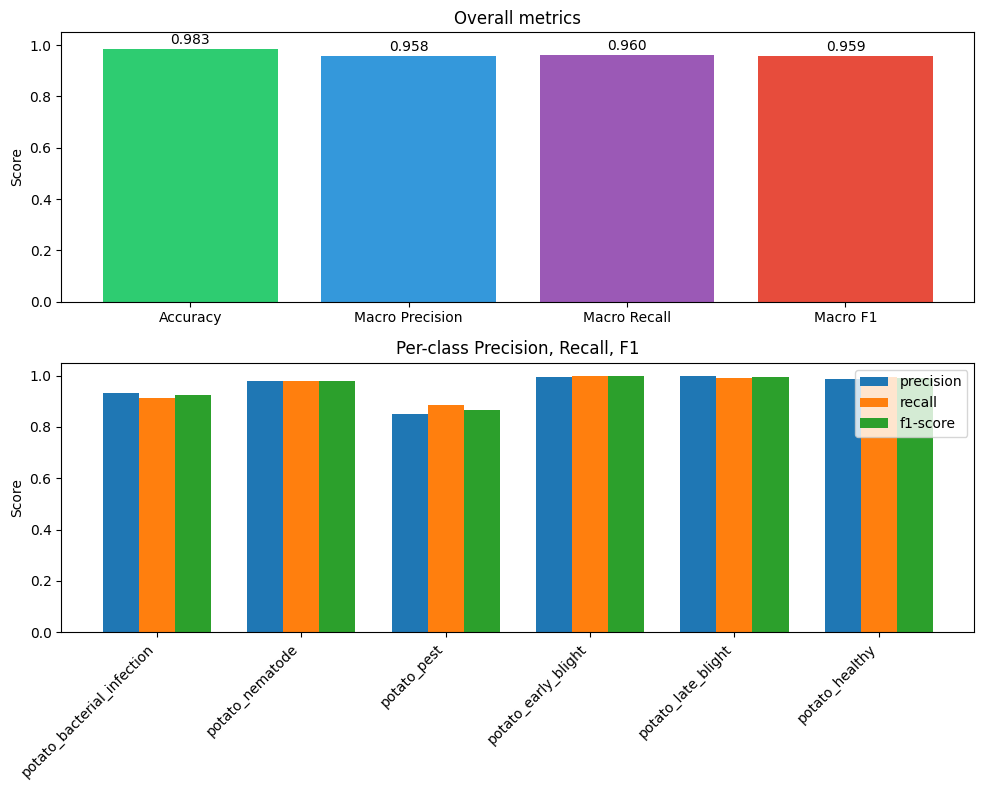

In [10]:
report_dict = classification_report(all_labels, all_preds, target_names=export_class_names, output_dict=True)
accuracy = report_dict["accuracy"]
macro_p = report_dict["macro avg"]["precision"]
macro_r = report_dict["macro avg"]["recall"]
macro_f1 = report_dict["macro avg"]["f1-score"]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

ax0 = axes[0]
overall_names = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
overall_vals = [accuracy, macro_p, macro_r, macro_f1]
bars = ax0.bar(overall_names, overall_vals, color=["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"])
ax0.set_ylabel("Score")
ax0.set_ylim(0, 1.05)
ax0.set_title("Overall metrics")
for b, v in zip(bars, overall_vals):
    ax0.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"{v:.3f}", ha="center", fontsize=10)

ax1 = axes[1]
x = np.arange(len(export_class_names))
width = 0.25
for i, m in enumerate(["precision", "recall", "f1-score"]):
    vals = [report_dict[c][m] for c in export_class_names]
    ax1.bar(x + width * (i - 1), vals, width, label=m)
ax1.set_xticks(x)
ax1.set_xticklabels(export_class_names, rotation=45, ha="right")
ax1.set_ylabel("Score")
ax1.set_title("Per-class Precision, Recall, F1")
ax1.legend()
ax1.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

**Confusion matrix (heatmap)**

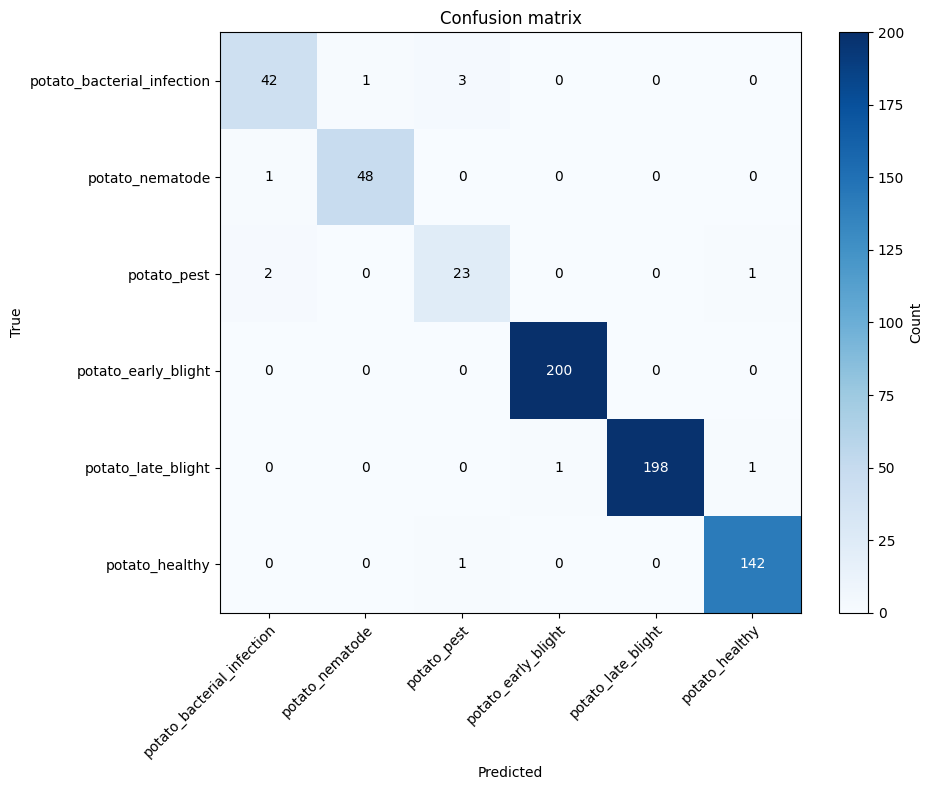

In [11]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(len(export_class_names)))
ax.set_yticks(np.arange(len(export_class_names)))
ax.set_xticklabels(export_class_names)
ax.set_yticklabels(export_class_names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(export_class_names)):
    for j in range(len(export_class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")
plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()